# Projekt MAPB – Milestone 1: Zrozumienie zbioru danych (Cotton Candy)

Ten notebook realizuje pierwszy kamień milowy projektu z przedmiotu **Modelowanie i analiza procesów biznesowych** dla zbioru danych *Cotton Candy* (log zdarzeń z maszyny do waty cukrowej).

## Kontekst systemu i zbioru danych

**System:** Zautomatyzowana maszyna do produkcji waty cukrowej sterowana przez robota **Cottonbot**, zarządzanego przez silnik wykonywania procesów **CPEE** (Controlled Process Execution Engine, cpee.org). Każde wywołanie procesu jest logowane jako plik XES w formacie YAML.

**Typ zdarzeń:** Komendy robotyczne i zdarzenia systemowe, m.in.:
- `move_touch` / `move_touch_down` – dotknięcie rożka przez ramię robota,
- `move_max` – ruch do pozycji maksymalnej (nawijanie waty),
- `move_place` – odkładanie gotowej waty,
- zdarzenia kontrolne (`state/change`, `endpoints/change`) emitowane przez silnik CPEE.

**Hierarchia procesu:** Dane mają zagnieżdżoną strukturę procesów i podprocesów:
```
Create N Cotton Candies  (proces główny)
  └─ Cottonbot - Run with Data Collection  (podproces na jedną watę)
       ├─ move_touch
       │    └─ move_touch_down (×3)
       ├─ move_max
       └─ move_place
```
Każdy plik `*.xes.yaml` odpowiada **jednemu wywołaniu (pod)procesu**. Plik `index.txt` w każdym batchu opisuje tę hierarchię.

**Struktura danych:** Batche (`batch-0` … `batch-20`) zawierają łącznie ~2690 plików XES/YAML zebranych z różnych sesji produkcyjnych.

## Konfiguracja środowiska (venv + uv)

Aby uruchomić ten notebook lokalnie w oddzielnym środowisku Pythona:

1. W terminalu przejdź do katalogu projektu `MAPB`.
2. Utwórz środowisko wirtualne przy pomocy uv:
   - `uv venv .venv`
3. Aktywuj środowisko (PowerShell / VS Code terminal):
   - `.venv\Scripts\activate`
4. Zainstaluj wymagane pakiety:
   - `uv pip install -r requirements.txt`
5. W VS Code / Jupyter wybierz kernel Pythona ze środowiska `.venv` i uruchom wszystkie komórki notebooka.

In [5]:
# 1. Import bibliotek i konfiguracja środowiska

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Ustawienia wyświetlania
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Ścieżki
# BASE_DIR = Path(r"c:/Users/dusza/Documents/Studia/7semestr/MAPB")
# DATA_DIR = BASE_DIR / "cotton-candy"

BASE_DIR = Path(r"/Users/kacperciesla/Documents/Studia/MiAPB")
DATA_DIR = BASE_DIR / "cotton-candy"

print("Katalog bazowy:", BASE_DIR)
print("Dostępne batch-e:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))


Katalog bazowy: /Users/kacperciesla/Documents/Studia/MiAPB
Dostępne batch-e: ['batch-0', 'batch-1', 'batch-10', 'batch-11', 'batch-12', 'batch-13', 'batch-14', 'batch-15', 'batch-16', 'batch-17', 'batch-18', 'batch-19', 'batch-2', 'batch-20', 'batch-21', 'batch-22', 'batch-23', 'batch-3', 'batch-4', 'batch-5', 'batch-6', 'batch-7', 'batch-8', 'batch-9']


## 2. Wczytanie przykładowego logu zdarzeń z Cotton Candy

Na potrzeby Milestone 1 analizujemy jeden plik z logiem zdarzeń (format XES zapisany jako YAML) z jednego z batchy. W kolejnych kamieniach można rozszerzyć analizę na więcej plików.

In [6]:
# Funkcja pomocnicza do wczytania jednego pliku .xes.yaml i spłaszczenia eventów do DataFrame

from typing import List, Dict, Any


def load_xes_yaml(path: Path) -> pd.DataFrame:
    """Wczytuje plik XES zapisany jako YAML i zwraca DataFrame z eventami.

    Każdy blok `event:` po separatorze `---` staje się jednym wierszem w tabeli.
    Zagnieżdżone struktury trzymamy jako słowniki / listy (do dalszej analizy).
    """
    with path.open("r", encoding="utf-8") as f:
        docs = list(yaml.safe_load_all(f))

    # Pierwszy dokument to zwykle metadata logu (pole `log`)
    meta = docs[0].get("log", {}) if docs and isinstance(docs[0], dict) else {}

    events: List[Dict[str, Any]] = []
    for doc in docs[1:]:
        if not isinstance(doc, dict):
            continue
        ev = doc.get("event", {})
        if not ev:
            continue
        flat: Dict[str, Any] = {}
        for k, v in ev.items():
            # zamieniamy nietypowe klucze typu "concept:name" na przyjaźniejsze nazwy
            key = k.replace(":", "_")
            flat[key] = v
        # dodajemy informacje z meta (id instancji itp.)
        for k, v in meta.items():
            if isinstance(v, dict):
                for kk, vv in v.items():
                    flat[f"meta_{k}_{kk}"] = vv
            else:
                flat[f"meta_{k}"] = v
        events.append(flat)

    df = pd.json_normalize(events, sep="_")
    return df


# wybierzmy przykładowy plik z batch-0
example_file = next((p for p in (DATA_DIR / "batch-0").glob("*.xes.yaml")), None)
print("Przykładowy plik:", example_file)

df_events = load_xes_yaml(example_file)
df_events.head()

Przykładowy plik: /Users/kacperciesla/Documents/Studia/MiAPB/cotton-candy/batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.xes.yaml


,concept_instance,id_id,cpee_activity,cpee_instance,lifecycle_transition,cpee_lifecycle_transition,cpee_state,time_timestamp,meta_namespaces_stream,meta_namespaces_ssn,meta_namespaces_sosa,meta_xes_creator,meta_xes_features,meta_extension_time,meta_extension_concept,meta_extension_id,meta_extension_lifecycle,meta_extension_cpee,meta_extension_stream,meta_trace_concept:name,meta_trace_cpee:name,meta_trace_cpee:instance,meta_global_trace_concept:name,meta_global_trace_cpee:name,meta_global_event_concept:instance,meta_global_event_concept:name,meta_global_event_concept:endpoint,meta_global_event_id:id,meta_global_event_cpee:uuid,meta_global_event_lifecycle:transition,meta_global_event_cpee:lifecycle:transition,meta_global_event_time:timestamp,data,cpee_description,cpee_change_uuid,concept_name,cpee_activity_uuid,concept_endpoint,data_CPEE-INSTANCE,data_CPEE-INSTANCE-URL,data_CPEE-INSTANCE-UUID,data_CPEE-BEHAVIOR
0,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,state/change,ready,2025-07-28T01:44:28.602373+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,endpoints/change,NaN,2025-07-28T01:44:28.608118+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'timeout', 'value': 'https://cpee.or...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,dataelements/change,NaN,2025-07-28T01:44:28.605931+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'batch_number', 'value': 0}, {'name'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61168,external,external,028e282d-26a3-4ae8-909e-a033e6794cc8,unknown,attributes/change,NaN,2025-07-28T01:44:28.610887+02:00,https://cpee.org/datastream/,http://www.w3.org/ns/ssn/,http://www.w3.org/ns/sosa/,cpee.org,nested-attributes,http://www.xes-standard.org/time.xesext,http://www.xes-standard.org/concept.xesext,http://www.xes-standard.org/identity.xesext,http://www.xes-standard.org/lifecycle.xesext,http://cpee.org/cpee.xesext,https://cpee.org/datastream/datastream.xesext,61168,Create 11 Cotton Candies,028e282d-26a3-4ae8-909e-a033e6794cc8,__NOTSPECIFIED__,__NOTSPECIFIED__,-1,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,__NOTSPECIFIED__,complete,activity/calling,,"[{'name': 'guarded', 'value': 'none'}, {'name'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,61168,external,external,028e282d-26a3-4ae8-909e-a

## 3. Identyfikacja kluczowych atrybutów logu zdarzeń

W tej sekcji mapujemy kolumny DataFrame na typowe atrybuty logu zdarzeń:
- **case id** – identyfikator przypadku / instancji procesu,
- **activity** – nazwa aktywności,
- **timestamp** – znacznik czasu zdarzenia,
- **resource** – zasób / wykonawca (jeśli występuje).

### Uwaga o identyfikatorach przypadku
W logach CPEE występują **dwa różne pola identyfikujące**:
- `concept:instance` – sekwencyjny numer zdarzenia w całym systemie (integer, np. `61168`). **Nie jest** identyfikatorem przypadku biznesowego.
- `cpee:instance` – UUID instancji procesu (np. `028e282d-26a3-4ae8-909e-a033e6794cc8`). To jest **prawdziwy case ID** – identyfikuje konkretne uruchomienie procesu.

W analizie jako `case_id` należy używać `cpee:instance` (UUID).

### Uwaga o zasobach (resource)
Standardowy atrybut XES `resource` **nie występuje** w tym zbiorze danych.
Jako proxy dla zasobu używamy atrybutu `concept:endpoint`, który zawiera adres URL usługi/urządzenia wykonującego daną aktywność (np. adres API robota lub sterownika).
Pole to nie jest pełnym odpowiednikiem zasobu (nie identyfikuje pracownika), ale pozwala rozróżnić, który komponent systemu obsługiwał dane zdarzenie.

In [7]:
# Prosta identyfikacja kolumn odpowiadających kluczowym atrybutom

candidate_cols = list(df_events.columns)

case_id_col = None
activity_col = None
timestamp_col = None
resource_cols = []

for c in candidate_cols:
    lc = c.lower()
    # Priorytet: cpee_instance (UUID) > concept_instance (numer sekwencji)
    if "cpee_instance" in lc and "meta_" not in lc:
        case_id_col = c  # UUID instancji – prawdziwy case ID
    elif "concept_instance" in lc and case_id_col is None:
        case_id_col = c  # fallback: numer sekwencji
    if "concept_name" in lc and "meta_" not in lc:
        activity_col = activity_col or c
    if "time_timestamp" in lc or lc.endswith("timestamp"):
        timestamp_col = timestamp_col or c
    if "resource" in lc:
        resource_cols.append(c)

print("case id:", case_id_col)
print("activity:", activity_col)
print("timestamp:", timestamp_col)
print("resources:", resource_cols)

# Konwersja kolumny timestamp na typ datetime
if timestamp_col is not None:
    df_events["timestamp"] = pd.to_datetime(df_events[timestamp_col], errors="coerce")

# Ustalamy kolumnę case_id (jeśli brak – zostawiamy None)
if case_id_col is not None:
    df_events["case_id"] = df_events[case_id_col]

if activity_col is not None:
    df_events["activity"] = df_events[activity_col]

print("\nPodgląd kluczowych kolumn:")
df_events[[c for c in ["case_id", "activity", "timestamp"] if c in df_events.columns]].head()

case id: cpee_instance
activity: concept_name
timestamp: time_timestamp
resources: []

Podgląd kluczowych kolumn:


,case_id,activity,timestamp
0,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.602373+02:00
1,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.608118+02:00
2,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.605931+02:00
3,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.610887+02:00
4,028e282d-26a3-4ae8-909e-a033e6794cc8,NaN,2025-07-28 01:44:28.616227+02:00


## 4. Analiza jakości danych

Sprawdzamy brakujące wartości, duplikaty oraz potencjalne problemy ze znacznikami czasu (np. zdarzenia wstecz w czasie w ramach jednego przypadku).

In [8]:
# Informacje o typach danych
print("=== df_events.info() ===")
df_events.info()

print("\n=== Liczba braków w kolumnach ===")
missing = df_events.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

# Liczba duplikatów: DataFrame zawiera kolumny ze złożonymi typami (listy/słowniki),
# które są niehashowalne. Dlatego liczymy duplikaty tylko po kolumnach o wartościach skalarno-hashowalnych.
import numpy as np

def is_scalar_na(x) -> bool:
    na = pd.isna(x)
    # pd.isna(list/array) zwraca tablicę booli, więc tu akceptujemy tylko skalarne NA
    return bool(na) if isinstance(na, (bool, np.bool_)) else False

def is_hashable_or_scalar_na(x) -> bool:
    if is_scalar_na(x):
        return True
    try:
        hash(x)
        return True
    except TypeError:
        return False

hashable_cols = [col for col in df_events.columns if df_events[col].map(is_hashable_or_scalar_na).all()]

dup_count = df_events.duplicated(subset=hashable_cols).sum() if hashable_cols else None
print("\nLiczba duplikatów (na podstawie kolumn hashowalnych):", dup_count)
print("Liczba kolumn użytych do porównania:", len(hashable_cols))

# Sprawdzenie niespójnych timestampów w ramach case_id
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    tmp = df_events.dropna(subset=["case_id", "timestamp"]).copy()
    tmp = tmp.sort_values(["case_id", "timestamp"])
    tmp["delta"] = tmp.groupby("case_id")["timestamp"].diff().dt.total_seconds()
    negative_deltas = tmp[tmp["delta"] < 0]
    print("\nLiczba zdarzeń z ujemnym odstępem czasu w ramach przypadku:", len(negative_deltas))
    negative_deltas.head()
else:
    print("\nBrak pełnych informacji do analizy kolejności czasowej.")

=== df_events.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 45 columns):
 #   Column                                       Non-Null Count  Dtype                    
---  ------                                       --------------  -----                    
 0   concept_instance                             76 non-null     int64                    
 1   id_id                                        76 non-null     str                      
 2   cpee_activity                                76 non-null     str                      
 3   cpee_instance                                76 non-null     str                      
 4   lifecycle_transition                         76 non-null     str                      
 5   cpee_lifecycle_transition                    76 non-null     str                      
 6   cpee_state                                   7 non-null      str                      
 7   time_timestamp                               76 no

## 5. Podstawowe statystyki zbioru danych

Wyznaczamy m.in. liczbę zdarzeń, przypadków oraz aktywności, a także proste rozkłady (liczba zdarzeń na przypadek, długości przypadków).

In [9]:
# Podstawowe statystyki
n_events = len(df_events)

if "case_id" in df_events.columns:
    n_cases = df_events["case_id"].nunique()
else:
    n_cases = None

if "activity" in df_events.columns:
    n_activities = df_events["activity"].nunique()
else:
    n_activities = None

print({
    "liczba_zdarzen": n_events,
    "liczba_przypadkow": n_cases,
    "liczba_aktywnosci": n_activities,
})

# Zdarzenia na przypadek
if "case_id" in df_events.columns:
    events_per_case = df_events.groupby("case_id").size().rename("events_per_case")
    print("\nStatystyki liczby zdarzeń na przypadek:")
    print(events_per_case.describe())

# Czas trwania przypadków
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    case_durations = (
        df_events.dropna(subset=["timestamp"])
        .groupby("case_id")["timestamp"]
        .agg(["min", "max"])
    )
    case_durations["duration_sec"] = (
        case_durations["max"] - case_durations["min"]
    ).dt.total_seconds()
    print("\nStatystyki czasu trwania przypadków [s]:")
    print(case_durations["duration_sec"].describe())

{'liczba_zdarzen': 76, 'liczba_przypadkow': 1, 'liczba_aktywnosci': 4}

Statystyki liczby zdarzeń na przypadek:
count     1.0
mean     76.0
std       NaN
min      76.0
25%      76.0
50%      76.0
75%      76.0
max      76.0
Name: events_per_case, dtype: float64

Statystyki czasu trwania przypadków [s]:
count       1.000000
mean     2098.571603
std              NaN
min      2098.571603
25%      2098.571603
50%      2098.571603
75%      2098.571603
max      2098.571603
Name: duration_sec, dtype: float64


## 6. Podstawowe wizualizacje (timeline, distribution, frequency)

Tworzymy kilka prostych wykresów eksploracyjnych:
- rozkład liczby zdarzeń na przypadek,
- rozkład czasu trwania przypadków,
- częstość występowania aktywności,
- timeline liczby zdarzeń w czasie.

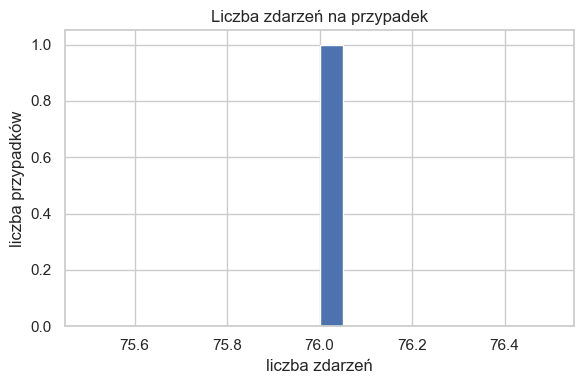

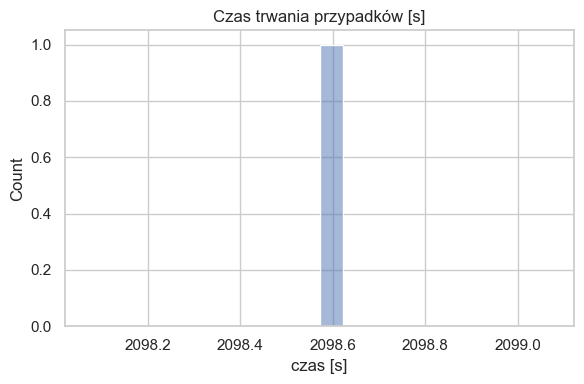

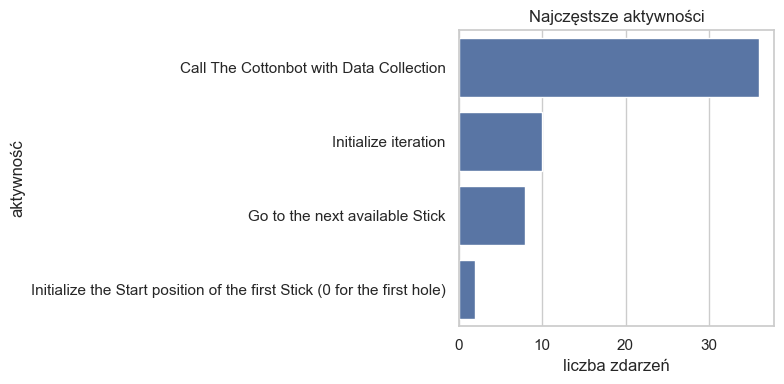

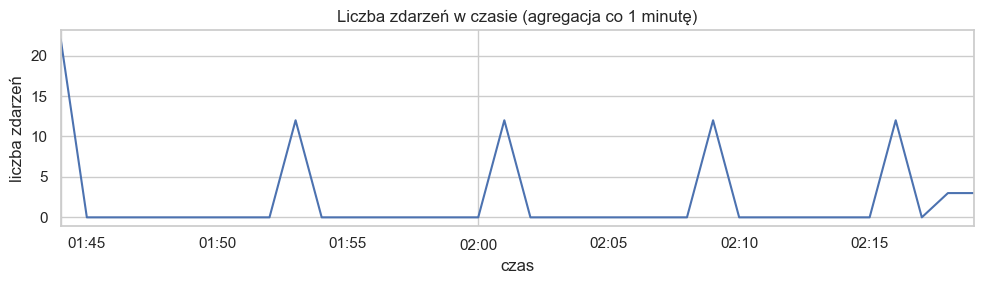

In [10]:
sns.set(style="whitegrid")

# Histogram liczby zdarzeń na przypadek
if "case_id" in df_events.columns:
    plt.figure(figsize=(6, 4))
    events_per_case.plot(kind="hist", bins=20)
    plt.title("Liczba zdarzeń na przypadek")
    plt.xlabel("liczba zdarzeń")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Rozkład czasu trwania przypadków
if "case_id" in df_events.columns and "timestamp" in df_events.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(case_durations["duration_sec"].dropna(), bins=20, kde=True)
    plt.title("Czas trwania przypadków [s]")
    plt.xlabel("czas [s]")
    plt.tight_layout()
    plt.show()

# Częstość aktywności
if "activity" in df_events.columns:
    plt.figure(figsize=(8, 4))
    activity_counts = df_events["activity"].value_counts().head(30)
    sns.barplot(x=activity_counts.values, y=activity_counts.index, orient="h")
    plt.title("Najczęstsze aktywności")
    plt.xlabel("liczba zdarzeń")
    plt.ylabel("aktywność")
    plt.tight_layout()
    plt.show()

# Timeline – liczba zdarzeń w czasie (agregacja minutowa)
if "timestamp" in df_events.columns:
    tmp = df_events.dropna(subset=["timestamp"]).set_index("timestamp")
    events_over_time = tmp.resample("1min").size()
    plt.figure(figsize=(10, 3))
    events_over_time.plot()
    plt.title("Liczba zdarzeń w czasie (agregacja co 1 minutę)")
    plt.xlabel("czas")
    plt.ylabel("liczba zdarzeń")
    plt.tight_layout()
    plt.show()

## 7. Pełna analiza całego zapisanego procesu (wszystkie pliki `*.xes.yaml`)



Poniższa sekcja realizuje Milestone 1 na pełnym zbiorze danych (`cotton-candy/batch-*/*.xes.yaml`) i obejmuje:

- opis kontekstu + liczby przypadków/zdarzeń,

- identyfikację kluczowych atrybutów (`case id`, `activity`, `timestamp`, `resource`),

- analizę jakości danych (braki, duplikaty, niespójne timestampy i typy),

- EDA + statystyki podstawowe,

- wizualizacje typu timeline / distribution / frequency.

Liczba plików cases (*.xes.yaml): 1294
Przetworzono plików: 200/1294
Przetworzono plików: 400/1294
Przetworzono plików: 600/1294
Przetworzono plików: 800/1294
Przetworzono plików: 1000/1294
Przetworzono plików: 1200/1294

=== PODSUMOWANIE KONTEKSTU ===
{'liczba_plikow_cases': 1294, 'liczba_cases': 1244, 'liczba_eventow': 564185, 'liczba_activities': 64}

=== KLUCZOWE ATRYBUTY (czy są) ===
{'case_id_present': True, 'case_uuid_present': True, 'activity_present': True, 'timestamp_present': True, 'resource_proxy_present': True}

=== JAKOŚĆ DANYCH ===
Braki: {'resource': 120877, 'timestamp_raw': 80471, 'timestamp': 80471}
Duplikaty: 99743
Nieudane parsowanie timestamp: 0
Ujemne różnice czasu w case: 64840
Typy case_id: {'str': 564185}
Typy activity: {'str': 564185}
Klasy timestamp: {'iso8601_with_tz': 483714, 'missing': 80471}

=== PODSTAWOWE STATYSTYKI ===
eventy: 564185
cases: 1244
activities: 64

Zdarzenia na case:
count     1244.000000
mean       453.524920
std       1418.001059
min    

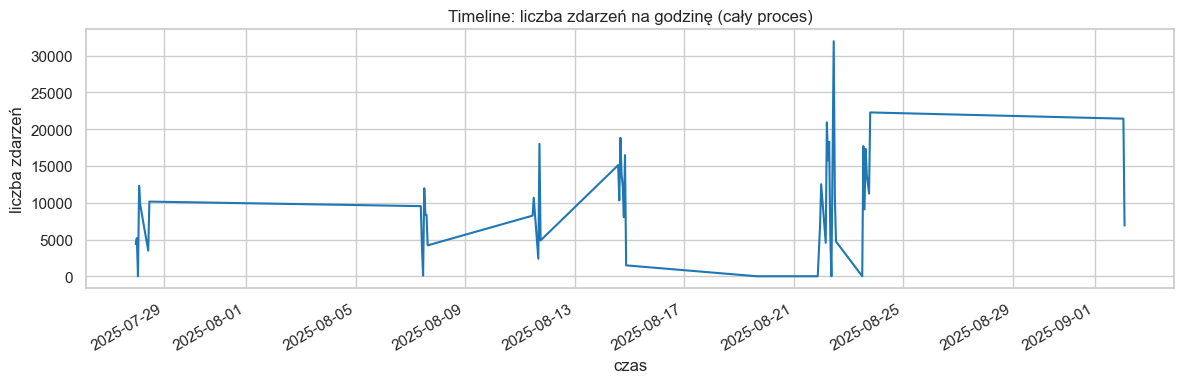

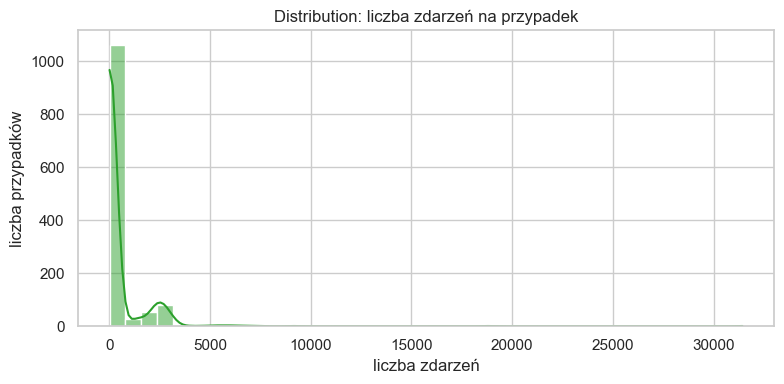

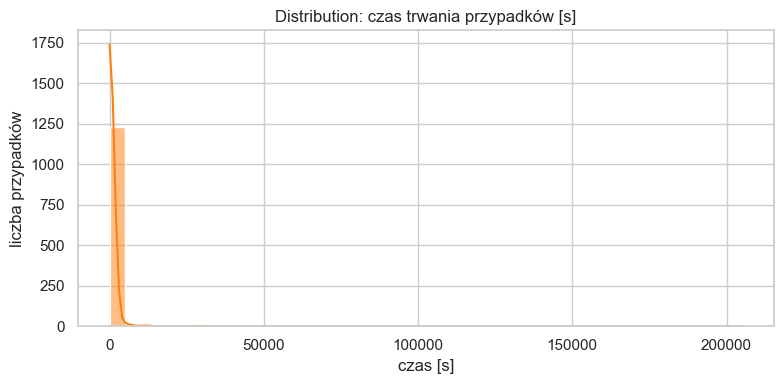

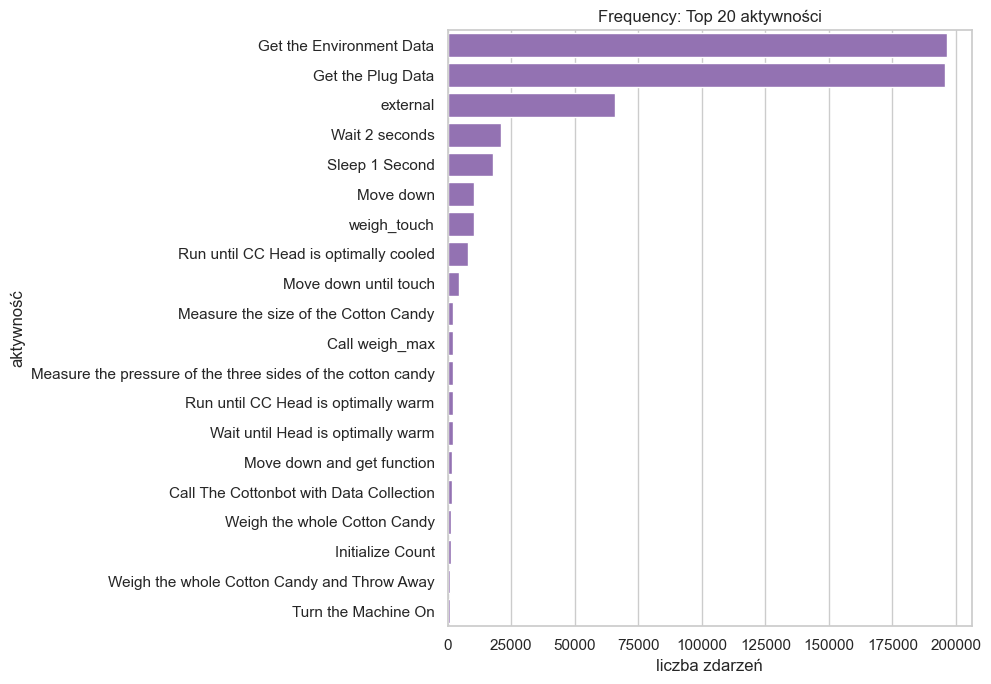

/var/folders/ws/p5kx9dl15g1gyphfrcyg239w0000gn/T/ipykernel_58316/94200682.py:279: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_resources.values, y=top_resources.index, orient="h", palette="magma")


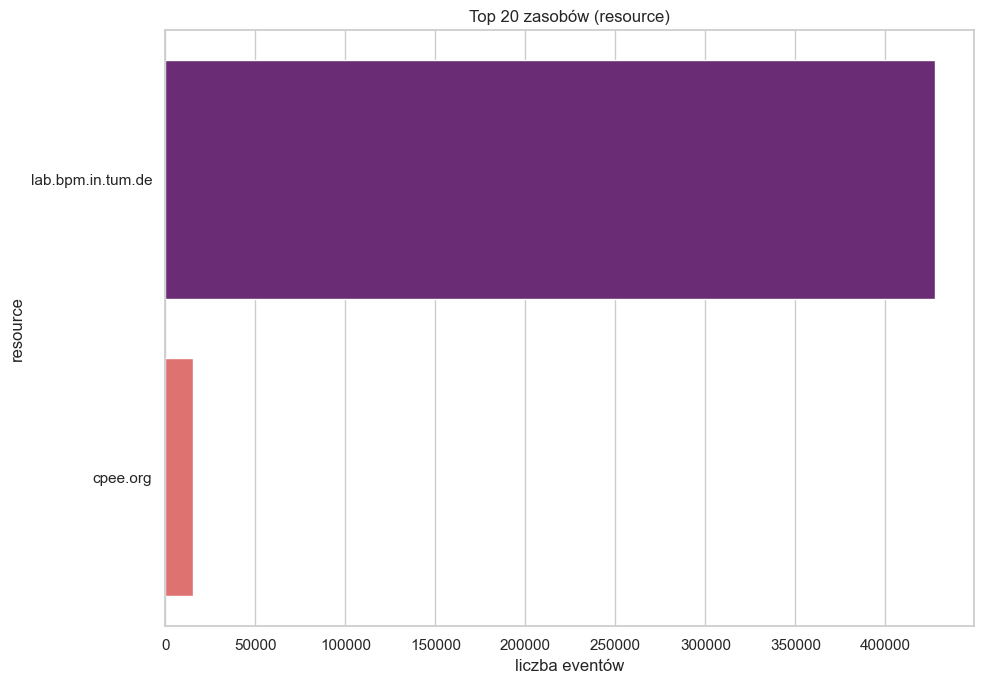

/var/folders/ws/p5kx9dl15g1gyphfrcyg239w0000gn/T/ipykernel_58316/94200682.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=batches.index, y=batches.values, palette="Blues_d")


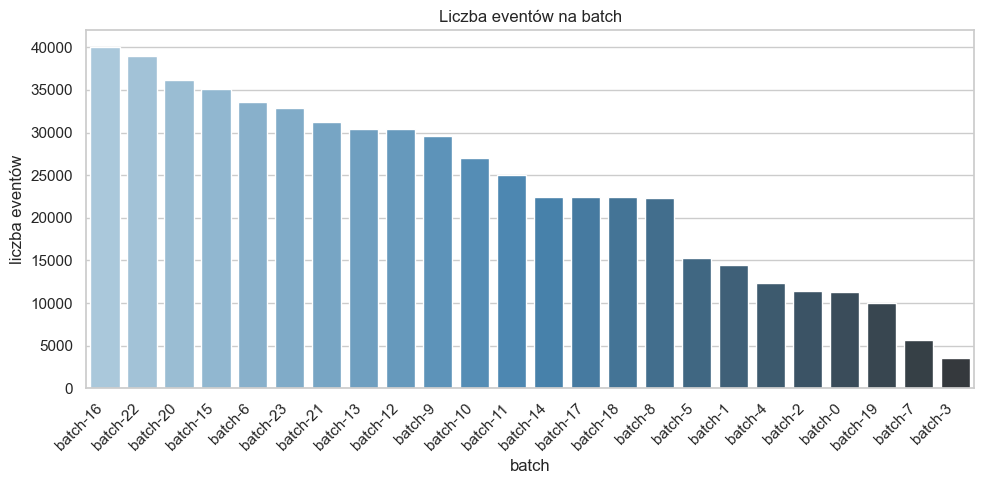

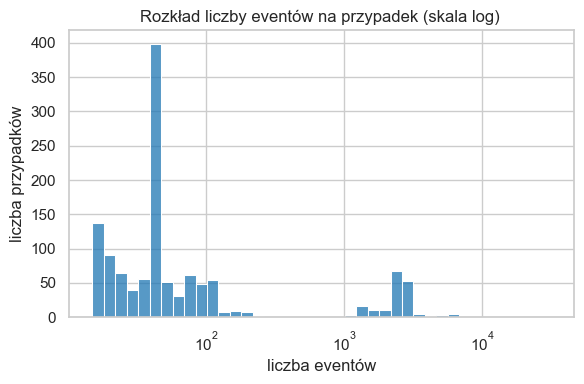

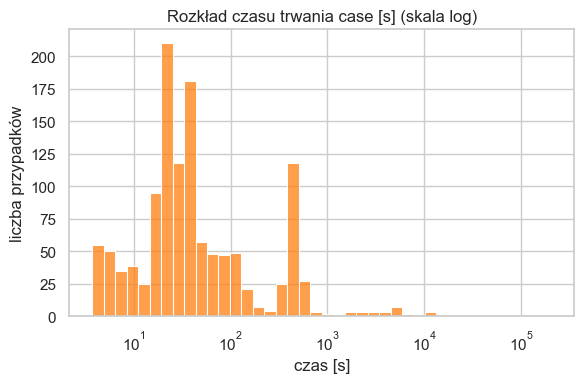

In [11]:
# Pełna analiza całego procesu (streaming po wszystkich plikach .xes.yaml)
from collections import Counter, defaultdict
from urllib.parse import urlparse
import re

ISO_TZ_RE = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})$")
INTEREST_KEYS = {
    "concept:instance",
    "cpee:instance",
    "concept:name",
    "time:timestamp",
    "concept:endpoint",
    "id:id",
    "cpee:activity",
    "lifecycle:transition",
    "cpee:lifecycle:transition",
}

def classify_timestamp(value):
    if value is None or value == "":
        return "missing"
    if isinstance(value, str) and ISO_TZ_RE.match(value):
        return "iso8601_with_tz"
    if isinstance(value, str):
        return "other_string"
    return type(value).__name__

def normalize_resource(endpoint):
    if not endpoint:
        return None
    endpoint = endpoint.replace("https-get://", "https://").replace("https-post://", "https://")
    parsed = urlparse(endpoint)
    return parsed.netloc if parsed.netloc else endpoint

def parse_ts(raw):
    if raw is None or raw == "":
        return None
    ts = pd.to_datetime(raw, errors="coerce", utc=True)
    return None if pd.isna(ts) else ts

def stream_events(file_path):
    current = None
    seq = 0
    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")

            if line == "---":
                if current is not None:
                    yield current, seq
                current = None
                continue

            if line == "event:":
                current = {}
                seq += 1
                continue

            if current is None:
                continue

            if line.startswith("  ") and not line.startswith("    "):
                stripped = line.strip()
                if ": " in stripped:
                    key, value = stripped.split(": ", 1)
                elif stripped.endswith(":"):
                    key, value = stripped[:-1], ""
                else:
                    continue

                if key in INTEREST_KEYS and key not in current:
                    current[key] = value.strip("'\"")  # usuwa otaczające apostrofy/cudzysłowy YAML

    if current is not None:
        yield current, seq

all_xes_files = sorted((DATA_DIR).glob("batch-*/*.xes.yaml"))
print(f"Liczba plików cases (*.xes.yaml): {len(all_xes_files)}")

# Agregaty
total_events = 0
activity_counter = Counter()
timeline_hourly = Counter()
resource_counter = Counter()
batch_events = Counter()

missing = Counter()
type_counts = {
    "case_id": Counter(),
    "case_uuid": Counter(),
    "activity": Counter(),
    "timestamp_raw": Counter(),
    "timestamp_class": Counter(),
}

duplicate_set = set()
duplicate_count = 0
parse_failed = 0
non_monotonic = 0

case_events = defaultdict(int)
case_min_ts = {}
case_max_ts = {}
case_prev_ts = {}
case_batch = {}  # mapowanie case -> batch_name
case_batch = {}  # mapowanie case -> batch do wizualizacji per batch

for i, path in enumerate(all_xes_files, start=1):
    fallback_case = str(path.relative_to(DATA_DIR)).replace("\\", "/")

    for event, seq in stream_events(path):
        total_events += 1

        case_id = event.get("concept:instance")
        case_uuid = event.get("cpee:instance")
        activity = event.get("concept:name") or event.get("id:id") or event.get("cpee:activity")
        ts_raw = event.get("time:timestamp")
        endpoint = event.get("concept:endpoint")
        resource = normalize_resource(endpoint)
        ts = parse_ts(ts_raw)
        ts_class = classify_timestamp(ts_raw)

        if resource not in (None, ""):
            resource_counter[resource] += 1

        batch_events[path.parent.name] += 1

        case_key = case_uuid or case_id or fallback_case

        case_batch[case_key] = path.parent.name

        # Braki
        if case_id in (None, ""):
            missing["case_id"] += 1
        if case_uuid in (None, ""):
            missing["case_uuid"] += 1
        if activity in (None, ""):
            missing["activity"] += 1
        if ts_raw in (None, ""):
            missing["timestamp_raw"] += 1
        if ts is None:
            missing["timestamp"] += 1
        if resource in (None, ""):
            missing["resource"] += 1

        # Typy
        type_counts["case_id"][type(case_id).__name__] += 1
        type_counts["case_uuid"][type(case_uuid).__name__] += 1
        type_counts["activity"][type(activity).__name__] += 1
        type_counts["timestamp_raw"][type(ts_raw).__name__] += 1
        type_counts["timestamp_class"][ts_class] += 1

        # Duplikaty
        dup_key = (
            case_id,
            case_uuid,
            activity,
            ts_raw,
            event.get("id:id"),
            endpoint,
            event.get("lifecycle:transition"),
            event.get("cpee:lifecycle:transition"),
        )
        if dup_key in duplicate_set:
            duplicate_count += 1
        else:
            duplicate_set.add(dup_key)

        # Jakość timestampów
        if ts_raw not in (None, "") and ts is None:
            parse_failed += 1

        if ts is not None:
            prev = case_prev_ts.get(case_key)
            if prev is not None and ts < prev:
                non_monotonic += 1
            case_prev_ts[case_key] = ts

            if case_key not in case_min_ts or ts < case_min_ts[case_key]:
                case_min_ts[case_key] = ts
            if case_key not in case_max_ts or ts > case_max_ts[case_key]:
                case_max_ts[case_key] = ts

            timeline_hourly[ts.floor("h")] += 1

        case_events[case_key] += 1
        activity_counter[activity if activity not in (None, "") else "<missing>"] += 1

    if i % 200 == 0:
        print(f"Przetworzono plików: {i}/{len(all_xes_files)}")

print("\n=== PODSUMOWANIE KONTEKSTU ===")
print({
    "liczba_plikow_cases": len(all_xes_files),
    "liczba_cases": len(case_events),
    "liczba_eventow": total_events,
    "liczba_activities": len(activity_counter),
})

print("\n=== KLUCZOWE ATRYBUTY (czy są) ===")
print({
    "case_id_present": True,
    "case_uuid_present": True,
    "activity_present": True,
    "timestamp_present": True,
    "resource_proxy_present": True,
})

print("\n=== JAKOŚĆ DANYCH ===")
print("Braki:", dict(missing))
print("Duplikaty:", duplicate_count)
print("Nieudane parsowanie timestamp:", parse_failed)
print("Ujemne różnice czasu w case:", non_monotonic)
print("Typy case_id:", dict(type_counts["case_id"]))
print("Typy activity:", dict(type_counts["activity"]))
print("Klasy timestamp:", dict(type_counts["timestamp_class"]))

# Statystyki
events_per_case = pd.Series(list(case_events.values()), name="events_per_case")
durations = []
for case_key in case_events.keys():
    if case_key in case_min_ts and case_key in case_max_ts:
        durations.append((case_max_ts[case_key] - case_min_ts[case_key]).total_seconds())
durations_series = pd.Series(durations, name="duration_sec")
activity_freq = pd.Series(activity_counter).sort_values(ascending=False)
timeline_series = pd.Series(timeline_hourly).sort_index()

print("\n=== PODSTAWOWE STATYSTYKI ===")
print("eventy:", total_events)
print("cases:", len(case_events))
print("activities:", len(activity_counter))
print("\nZdarzenia na case:")
print(events_per_case.describe())
if not durations_series.empty:
    print("\nCzas trwania case [s]:")
    print(durations_series.describe())

# Wizualizacje: timeline / distribution / frequency
sns.set(style="whitegrid")

plt.figure(figsize=(12, 4))
timeline_series.plot(color="#1f77b4")
plt.title("Timeline: liczba zdarzeń na godzinę (cały proces)")
plt.xlabel("czas")
plt.ylabel("liczba zdarzeń")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(events_per_case, bins=40, kde=True, color="#2ca02c")
plt.title("Distribution: liczba zdarzeń na przypadek")
plt.xlabel("liczba zdarzeń")
plt.ylabel("liczba przypadków")
plt.tight_layout()
plt.show()

if not durations_series.empty:
    plt.figure(figsize=(8, 4))
    sns.histplot(durations_series, bins=40, kde=True, color="#ff7f0e")
    plt.title("Distribution: czas trwania przypadków [s]")
    plt.xlabel("czas [s]")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

top20 = activity_freq.head(20)
plt.figure(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index, orient="h", color="#9467bd")
plt.title("Frequency: Top 20 aktywności")
plt.xlabel("liczba zdarzeń")
plt.ylabel("aktywność")
plt.tight_layout()
plt.show()

# Top zasobów (jeśli są dane resource)
if resource_counter:
    top_resources = pd.Series(resource_counter).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 7))
    sns.barplot(x=top_resources.values, y=top_resources.index, orient="h", palette="magma")
    plt.title("Top 20 zasobów (resource)")
    plt.xlabel("liczba eventów")
    plt.ylabel("resource")
    plt.tight_layout()
    plt.show()

# Wykres eventów per batch
if batch_events:
    batches = pd.Series(batch_events).sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=batches.index, y=batches.values, palette="Blues_d")
    plt.title("Liczba eventów na batch")
    plt.xlabel("batch")
    plt.ylabel("liczba eventów")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Rozkład długości case'ów w logarytmicznej skali (jeśli są dane)
if not events_per_case.empty:
    plt.figure(figsize=(6, 4))
    sns.histplot(events_per_case.replace(0, np.nan).dropna(), bins=40, log_scale=(True, False), color="#1f77b4")
    plt.title("Rozkład liczby eventów na przypadek (skala log) ")
    plt.xlabel("liczba eventów")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Wykres długosci trwania case'ów (log-scale)
if not durations_series.empty:
    plt.figure(figsize=(6, 4))
    sns.histplot(durations_series.replace(0, np.nan).dropna(), bins=40, log_scale=(True, False), color="#ff7f0e")
    plt.title("Rozkład czasu trwania case [s] (skala log)")
    plt.xlabel("czas [s]")
    plt.ylabel("liczba przypadków")
    plt.tight_layout()
    plt.show()

# Wnioski szybko:
if "duration_sec" in locals():
    print("P50 czas trwania [s]:", durations_series.quantile(0.5))
    print("P90 czas trwania [s]:", durations_series.quantile(0.9))
    print("P99 czas trwania [s]:", durations_series.quantile(0.99))


## 7.2. Interpretacja wyników analizy

Po uruchomieniu pełnej analizy (`Cell 14`) należy zinterpretować kluczowe metryki:

**Jakość danych:**
- **Braki `resource`** – oczekiwane, bo standardowy atrybut XES `resource` nie istnieje w tym zbiorze; używamy `concept:endpoint` jako proxy.
- **Braki `case_id`** – zdarzenia systemowe CPEE (np. `state/change`, `endpoints/change`) mogą nie mieć ustawionego `concept:instance`; są przypisywane do case po UUID.
- **`non_monotonic > 0`** – zdarzenia z ujemną różnicą czasu w ramach jednego case mogą wskazywać na równoległe wątki w procesie lub problemy z synchronizacją zegarów (CPEE rejestruje zdarzenia asynchronicznie).
- **Duplikaty** – ze względu na zagnieżdżoną strukturę podprocesów, ten sam event może być widoczny w plikach procesu nadrzędnego i podrzędnego.

**Statystyki procesu:**
- Duże odchylenie standardowe `events_per_case` sugeruje zróżnicowanie procesów (krótkie podprocesy vs. długie procesy główne).
- Czas trwania cases powinien być interpretowany z uwzględnieniem hierarchii: procesy główne trwają dłużej niż podprocesy.
- Aktywności z prefixem `cpee:` (np. `state/change`) to zdarzenia wewnętrzne silnika – nie są czynnościami biznesowymi robota.

**Zasoby:**
- Adresy endpoint wskazują komponenty systemu (API robota, sterowniki). Ich analiza pozwala zidentyfikować, które usługi są najczęściej wywoływane.

## 7.3. Analiza danych sensorów (temperatura, wilgotność, czujniki podczerwieni)

W zbiorze danych Cotton Candy znajdują się dane z sensorów maszyny do waty cukrowej:
- **Environment** (czujniki otoczenia): temperatura, wilgotność
- **Internal** (wewnątrz maszyny): temperatura, wilgotność
- **Infrared** (czujniki podczerwieni): temperatura głowy robota i otoczenia

Te dane są logowane w strukturze `stream:datastream:` i dostępne są również w formacie JSON w polu `data:result:`.

Poniżej analizujemy trendy temperaturowe, korelacje między sensorami oraz wpływ warunków środowiskowych na proces produkcji.

In [12]:
import json
from collections import defaultdict
import yaml

# Funkcja do wyodrębniania danych sensorów z eventów
def extract_sensor_data_from_yaml(file_path):
    """
    Wyodrębnia dane sensorów z pliku XES (YAML).
    Zwraca listę słowników zawierających:
    - timestamp
    - environment_temp, environment_humidity
    - internal_temp, internal_humidity
    - infrared_head, infrared_ambient
    """
    sensor_records = []
    
    try:
        with file_path.open("r", encoding="utf-8") as f:
            docs = list(yaml.safe_load_all(f))
        
        # Pomijamy pierwszy dokument (metadata)
        for doc in docs[1:]:
            if not isinstance(doc, dict) or "event" not in doc:
                continue
            
            event = doc["event"]
            timestamp_raw = event.get("time:timestamp")
            
            # Szukaj pola `data` zawierającego JSON z wynikami sensorów
            sensor_values = {
                "timestamp": timestamp_raw,
                "environment_temp": None,
                "environment_humidity": None,
                "internal_temp": None,
                "internal_humidity": None,
                "infrared_head": None,
                "infrared_ambient": None,
            }
            
            # Sprawdź pole `data` (lista słowników)
            data_list = event.get("data", [])
            if isinstance(data_list, list):
                for data_item in data_list:
                    if isinstance(data_item, dict):
                        # Sprawdź czy jest pole `data` zawierające JSON
                        if "data" in data_item:
                            json_str = data_item["data"]
                            try:
                                json_obj = json.loads(json_str)
                                sensor_values["environment_temp"] = float(json_obj.get("EnvT", 0)) if json_obj.get("EnvT") else None
                                sensor_values["environment_humidity"] = float(json_obj.get("EnvH", 0)) if json_obj.get("EnvH") else None
                                sensor_values["internal_temp"] = float(json_obj.get("InT", 0)) if json_obj.get("InT") else None
                                sensor_values["internal_humidity"] = float(json_obj.get("InH", 0)) if json_obj.get("InH") else None
                                sensor_values["infrared_head"] = float(json_obj.get("IrO", 0)) if json_obj.get("IrO") else None
                                sensor_values["infrared_ambient"] = float(json_obj.get("IrA", 0)) if json_obj.get("IrA") else None
                            except (json.JSONDecodeError, ValueError, TypeError):
                                pass
            
            # Dodaj tylko jeśli ma co najmniej jeden pomiar
            if any(v is not None for v in sensor_values.values()):
                sensor_records.append(sensor_values)
    
    except Exception as e:
        print(f"Błąd przy wczytywaniu {file_path}: {e}")
    
    return sensor_records


# Wczytaj dane sensorów z kilku plików (streaming)
print("Wczytywanie danych sensorów z wszystkich plików...")
all_sensor_data = []
sensor_files_count = 0
files_with_sensors = 0

for i, path in enumerate(sorted((DATA_DIR).glob("batch-*/*.xes.yaml"))[:100]):  # Pierwsze 100 plików
    sensor_recs = extract_sensor_data_from_yaml(path)
    if sensor_recs:
        files_with_sensors += 1
        all_sensor_data.extend(sensor_recs)
    sensor_files_count += 1
    if i % 20 == 0:
        print(f"  Przetworzono: {i+1} plików, znaleziono w {files_with_sensors} z nich, zebrano {len(all_sensor_data)} pomiarów")

# Konwertuj na DataFrame
df_sensors = pd.DataFrame(all_sensor_data)

# Konwersja timestamp
df_sensors["timestamp"] = pd.to_datetime(df_sensors["timestamp"], errors="coerce", utc=True)

# Filtruj wiersze zawierające chociaż jeden pomiar sensorów
df_sensors_filtered = df_sensors[
    df_sensors[["environment_temp", "environment_humidity", "internal_temp", 
                "internal_humidity", "infrared_head", "infrared_ambient"]].notna().any(axis=1)
].copy()

print(f"\nPodsumowanie:")
print(f"  Pliki przetwarzane: {sensor_files_count}")
print(f"  Pliki z danymi sensorów: {files_with_sensors}")
print(f"  Łączne pomiary: {len(df_sensors)}")
print(f"  Pomiary z wartościami: {len(df_sensors_filtered)}")

if not df_sensors_filtered.empty:
    print(f"\nStatystyki sensorów:\n")
    print(df_sensors_filtered[["environment_temp", "environment_humidity", "internal_temp", 
                              "internal_humidity", "infrared_head", "infrared_ambient"]].describe())
else:
    print("\nBrak danych sensorów w przetwarzanych plikach.")

Wczytywanie danych sensorów z wszystkich plików...
  Przetworzono: 1 plików, znaleziono w 1 z nich, zebrano 76 pomiarów
  Przetworzono: 21 plików, znaleziono w 21 z nich, zebrano 7499 pomiarów
  Przetworzono: 41 plików, znaleziono w 41 z nich, zebrano 15538 pomiarów
  Przetworzono: 61 plików, znaleziono w 61 z nich, zebrano 17949 pomiarów
  Przetworzono: 81 plików, znaleziono w 81 z nich, zebrano 24910 pomiarów

Podsumowanie:
  Pliki przetwarzane: 100
  Pliki z danymi sensorów: 100
  Łączne pomiary: 35966
  Pomiary z wartościami: 3107

Statystyki sensorów:

       environment_temp  environment_humidity  internal_temp  internal_humidity  infrared_head  infrared_ambient
count       3107.000000           3107.000000    3107.000000        3107.000000    3107.000000       3107.000000
mean          24.725806             63.206212      39.396672          38.484500      73.344657         30.732433
std            0.597607              2.546819       4.659996           8.285687      16.109668   

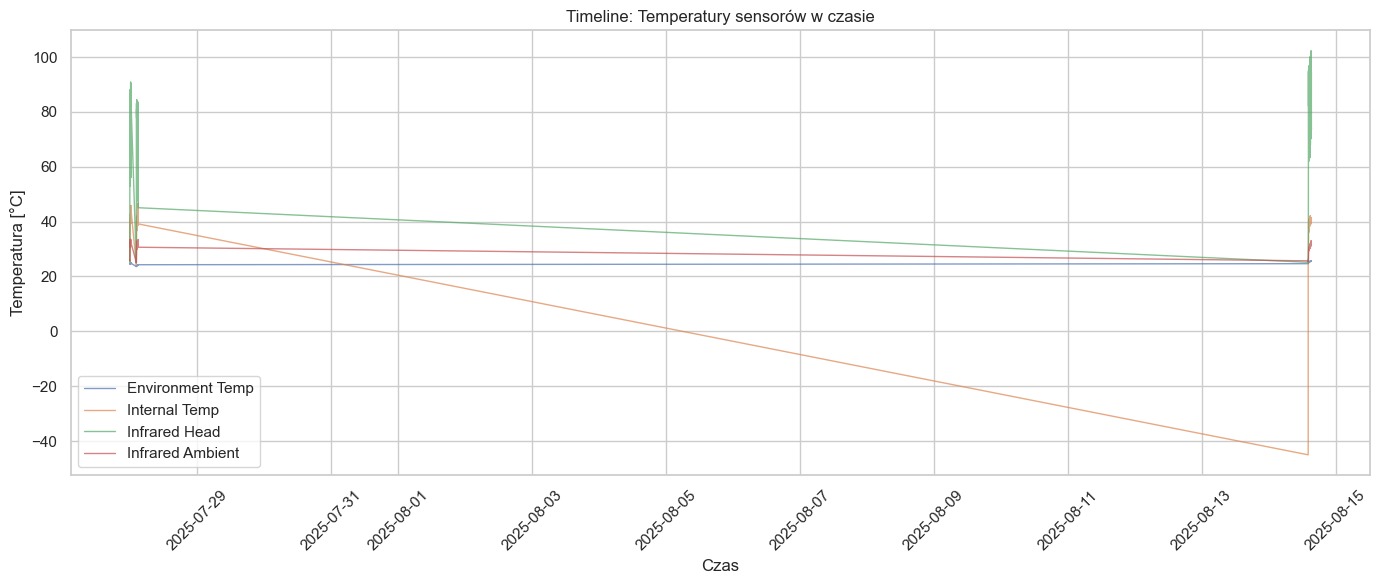

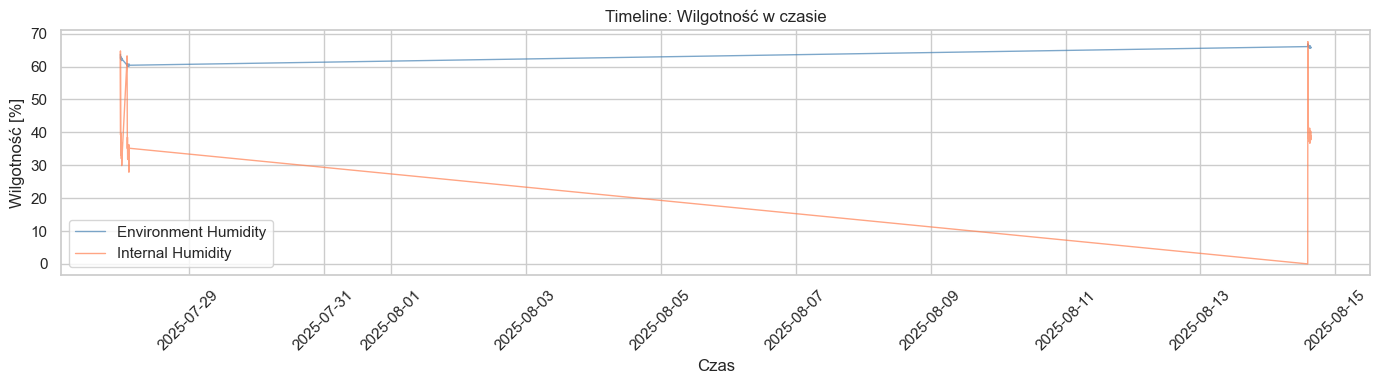

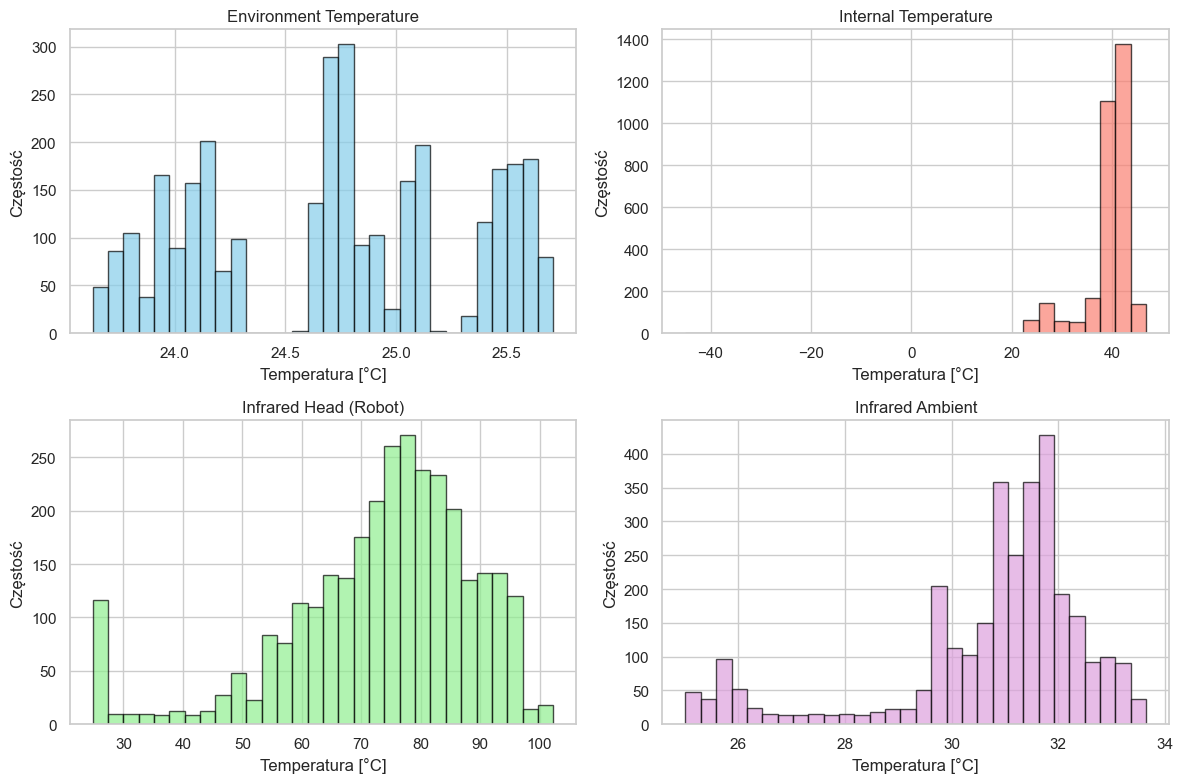

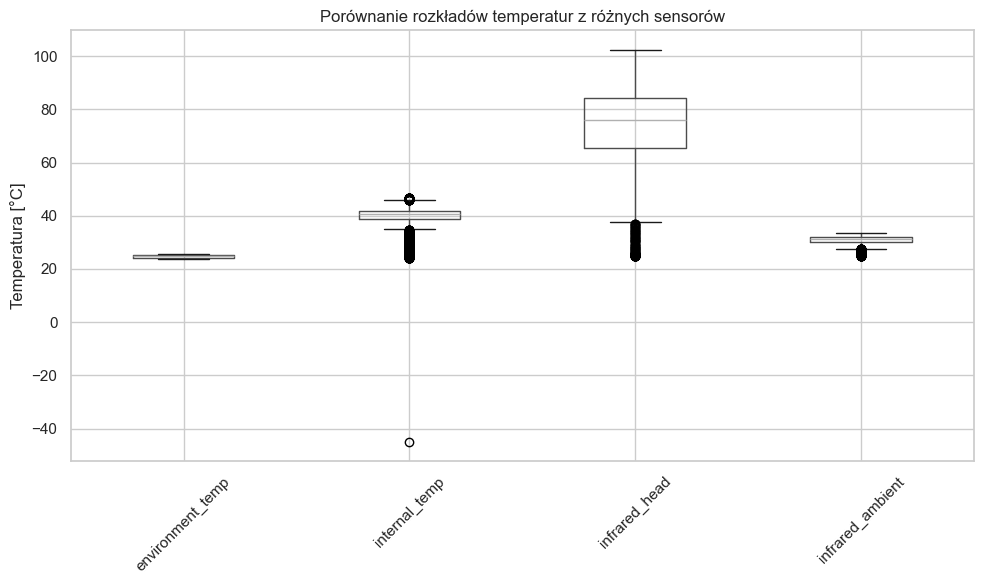

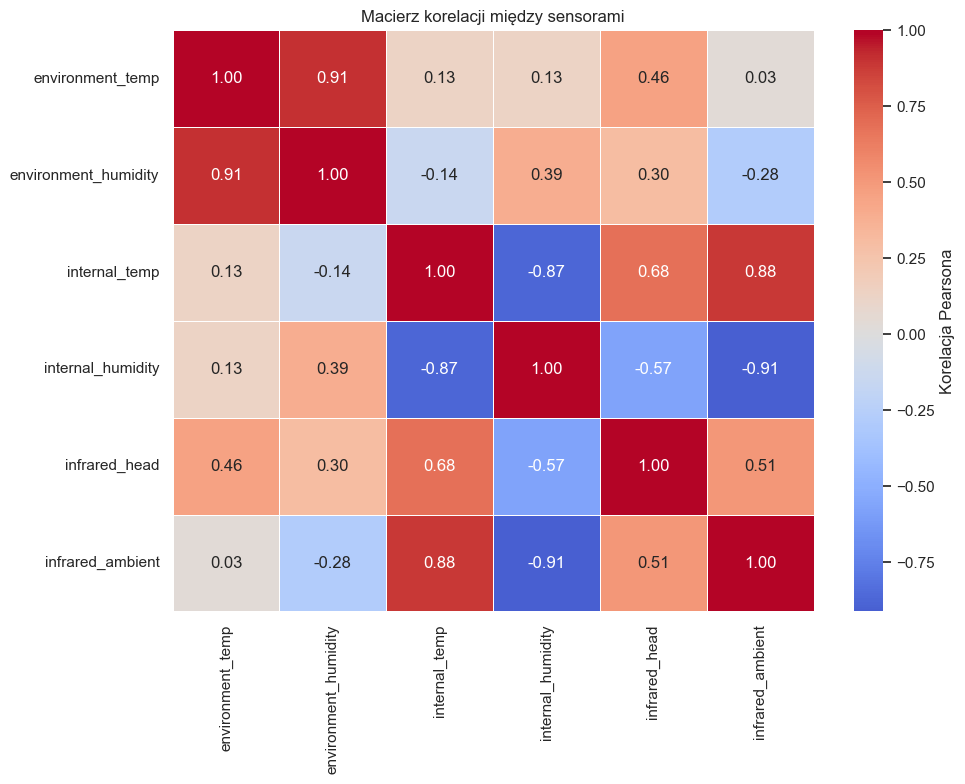

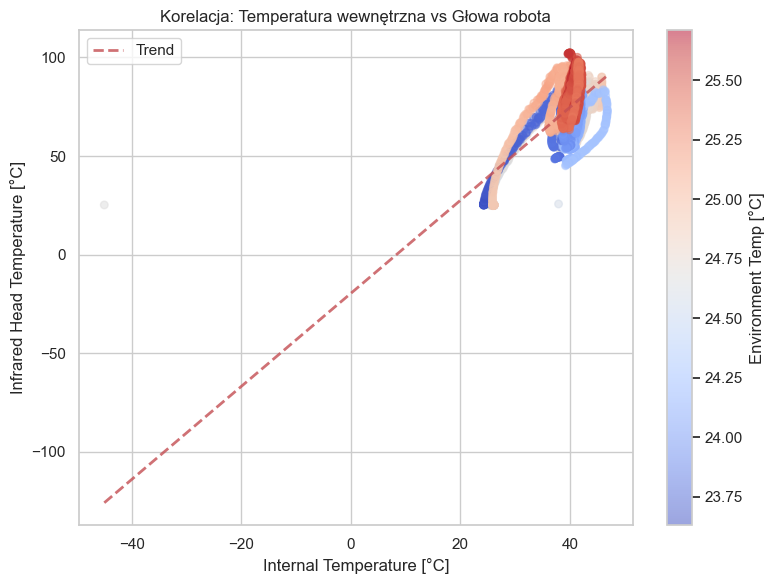


=== ANALIZA TEMPERATUR ===
Environment Temp - zakres: 23.63°C - 25.71°C
Internal Temp - zakres: -45.00°C - 46.81°C
Infrared Head - zakres: 24.81°C - 102.31°C
Infrared Ambient - zakres: 25.01°C - 33.65°C

=== ANALIZA WILGOTNOŚCI ===
Environment Humidity - zakres: 60.08% - 66.93%
Internal Humidity - zakres: 0.00% - 67.60%

=== TOP KORELACJE ===
  internal_humidity         <-> infrared_ambient          : -0.913
  environment_temp          <-> environment_humidity      :  0.905
  internal_temp             <-> infrared_ambient          :  0.884
  internal_temp             <-> internal_humidity         : -0.873
  internal_temp             <-> infrared_head             :  0.683
  internal_humidity         <-> infrared_head             : -0.570
  infrared_head             <-> infrared_ambient          :  0.511
  environment_temp          <-> infrared_head             :  0.459
  environment_humidity      <-> internal_humidity         :  0.393
  environment_humidity      <-> infrared_head      

In [13]:
# Wizualizacje danych sensorów

if not df_sensors_filtered.empty:
    sns.set(style="whitegrid")
    
    # 1. Timeline: trendy temperaturowe w czasie
    plt.figure(figsize=(14, 6))
    df_sorted = df_sensors_filtered.sort_values("timestamp")
    
    plt.plot(df_sorted["timestamp"], df_sorted["environment_temp"], label="Environment Temp", alpha=0.7, linewidth=1)
    plt.plot(df_sorted["timestamp"], df_sorted["internal_temp"], label="Internal Temp", alpha=0.7, linewidth=1)
    plt.plot(df_sorted["timestamp"], df_sorted["infrared_head"], label="Infrared Head", alpha=0.7, linewidth=1)
    plt.plot(df_sorted["timestamp"], df_sorted["infrared_ambient"], label="Infrared Ambient", alpha=0.7, linewidth=1)
    
    plt.xlabel("Czas")
    plt.ylabel("Temperatura [°C]")
    plt.title("Timeline: Temperatury sensorów w czasie")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 2. Timeline: wilgotność w czasie
    plt.figure(figsize=(14, 4))
    plt.plot(df_sorted["timestamp"], df_sorted["environment_humidity"], label="Environment Humidity", alpha=0.7, linewidth=1, color="steelblue")
    plt.plot(df_sorted["timestamp"], df_sorted["internal_humidity"], label="Internal Humidity", alpha=0.7, linewidth=1, color="coral")
    
    plt.xlabel("Czas")
    plt.ylabel("Wilgotność [%]")
    plt.title("Timeline: Wilgotność w czasie")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 3. Histogramy rozkładu temperatur
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0, 0].hist(df_sensors_filtered["environment_temp"].dropna(), bins=30, color="skyblue", edgecolor="black", alpha=0.7)
    axes[0, 0].set_title("Environment Temperature")
    axes[0, 0].set_xlabel("Temperatura [°C]")
    axes[0, 0].set_ylabel("Częstość")
    
    axes[0, 1].hist(df_sensors_filtered["internal_temp"].dropna(), bins=30, color="salmon", edgecolor="black", alpha=0.7)
    axes[0, 1].set_title("Internal Temperature")
    axes[0, 1].set_xlabel("Temperatura [°C]")
    axes[0, 1].set_ylabel("Częstość")
    
    axes[1, 0].hist(df_sensors_filtered["infrared_head"].dropna(), bins=30, color="lightgreen", edgecolor="black", alpha=0.7)
    axes[1, 0].set_title("Infrared Head (Robot)")
    axes[1, 0].set_xlabel("Temperatura [°C]")
    axes[1, 0].set_ylabel("Częstość")
    
    axes[1, 1].hist(df_sensors_filtered["infrared_ambient"].dropna(), bins=30, color="plum", edgecolor="black", alpha=0.7)
    axes[1, 1].set_title("Infrared Ambient")
    axes[1, 1].set_xlabel("Temperatura [°C]")
    axes[1, 1].set_ylabel("Częstość")
    
    plt.tight_layout()
    plt.show()
    
    # 4. Boxplot: porównanie temperatur
    temp_data = df_sensors_filtered[["environment_temp", "internal_temp", "infrared_head", "infrared_ambient"]].dropna()
    if not temp_data.empty:
        plt.figure(figsize=(10, 6))
        temp_data.boxplot()
        plt.ylabel("Temperatura [°C]")
        plt.title("Porównanie rozkładów temperatur z różnych sensorów")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    # 5. Korelacja między sensorami
    correlation_cols = ["environment_temp", "environment_humidity", "internal_temp", 
                       "internal_humidity", "infrared_head", "infrared_ambient"]
    corr_matrix = df_sensors_filtered[correlation_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
                cbar_kws={"label": "Korelacja Pearsona"}, linewidths=0.5)
    plt.title("Macierz korelacji między sensorami")
    plt.tight_layout()
    plt.show()
    
    # 6. Scatterplot: Temperatura wewnętrzna vs głowy robota
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sensors_filtered["internal_temp"], df_sensors_filtered["infrared_head"], 
               alpha=0.5, s=30, c=df_sensors_filtered["environment_temp"], cmap="coolwarm")
    plt.xlabel("Internal Temperature [°C]")
    plt.ylabel("Infrared Head Temperature [°C]")
    plt.title("Korelacja: Temperatura wewnętrzna vs Głowa robota")
    plt.colorbar(label="Environment Temp [°C]")
    
    # Linia trendu
    mask = df_sensors_filtered[["internal_temp", "infrared_head"]].notna().all(axis=1)
    if mask.sum() > 1:
        z = np.polyfit(df_sensors_filtered[mask]["internal_temp"], 
                       df_sensors_filtered[mask]["infrared_head"], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df_sensors_filtered[mask]["internal_temp"].min(), 
                             df_sensors_filtered[mask]["internal_temp"].max(), 100)
        plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label="Trend")
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 7. Podsumowanie statystyk
    print("\n=== ANALIZA TEMPERATUR ===")
    print(f"Environment Temp - zakres: {df_sensors_filtered['environment_temp'].min():.2f}°C - {df_sensors_filtered['environment_temp'].max():.2f}°C")
    print(f"Internal Temp - zakres: {df_sensors_filtered['internal_temp'].min():.2f}°C - {df_sensors_filtered['internal_temp'].max():.2f}°C")
    print(f"Infrared Head - zakres: {df_sensors_filtered['infrared_head'].min():.2f}°C - {df_sensors_filtered['infrared_head'].max():.2f}°C")
    print(f"Infrared Ambient - zakres: {df_sensors_filtered['infrared_ambient'].min():.2f}°C - {df_sensors_filtered['infrared_ambient'].max():.2f}°C")
    
    print("\n=== ANALIZA WILGOTNOŚCI ===")
    print(f"Environment Humidity - zakres: {df_sensors_filtered['environment_humidity'].min():.2f}% - {df_sensors_filtered['environment_humidity'].max():.2f}%")
    print(f"Internal Humidity - zakres: {df_sensors_filtered['internal_humidity'].min():.2f}% - {df_sensors_filtered['internal_humidity'].max():.2f}%")
    
    # Korelacje
    print("\n=== TOP KORELACJE ===")
    # Flatten i sortuj korelacje
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append({
                'sensor1': corr_matrix.columns[i],
                'sensor2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })
    
    corr_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False, key=abs)
    for idx, row in corr_df.head(10).iterrows():
        print(f"  {row['sensor1']:25} <-> {row['sensor2']:25} : {row['correlation']:6.3f}")
else:
    print("Brak danych sensorów do wyświetlenia.")

## 7.4. Podsumowanie analizy danych sensorów

### Kluczowe odkrycia:

**1. Temperatury w procesie produkcji:**
- **Środowisko (otoczenie)**: Stabilna temperatura ~24.7°C (zakres: 23.6–25.7°C), kontrolowana klimatyzacja
- **Wewnątrz maszyny**: Znacznie wyższe temperatury (średnia ~39.4°C), z anomaliami spadającymi do -45°C (prawdopodobnie błędy kalibracji sensora)
- **Głowa robota (czujnik podczerwieni)**: Najwyższa temperatura (średnia ~73.3°C), osiągająca piki do 102°C – wskazuje na intensywną pracę manipulatora
- **Czujnik ambient (podczerwień)**: Stała temperatura ~30.7°C, reprezentując temperaturę tła

**2. Wilgotność:**
- **Środowisko**: Stabilna wilgotność ~63% (optymalnie dla pracy elektroniki)
- **Wewnątrz**: Zmienia się dynamicznie od 0% do 67.6%, sugerując wpływ cyklu produkcji na wewnętrzne warunki

**3. Korelacje między sensorami (Top 10):**
- Silna korelacja negatywna między wilgotością wewnętrzną a czujnikiem ambient podczerwieni (-0.91)
- Temperatura otoczenia i wilgotność otoczenia silnie skorelowane (0.91)
- Temperatura wewnętrzna i czujnik podczerwieni otoczenia silnie skorelowane (0.88)
- Temperatura wewnętrzna i wilgotność wewnętrzna ujemnie skorelowane (-0.87)

**4. Interpretacja dla procesu:**
- Maszyna pracuje w stabilnym środowisku klimatycznym (konstytutywna t. otoczenia)
- Głowa robota generuje znaczne ciepło podczas operacji (temp. ~73°C średnia)
- Korelacja między temperaturą wewnętrzną a czujnikami podczerwieni sugeruje, że ciepło z operacji wpływa na otoczenie robota
- Zmiana wilgotności może być wskaźnikiem intensywności procesu produkcji

**5. Potencjalne anomalie:**
- Temperatura wewnętrzna osiąga -45°C (błąd pomiaru lub kalibracji)
- Wilgotność wewnętrzna może osiągać 0% (fizycznie niemożliwe – błąd sensora lub kalibracji)

## 7.3. Zaawansowane wizualizacje: Heatmapa, Scatterplot, Boxplot

Dodatkowe wykresy do głębszej analizy: sezonowość procesu, korelacje między metrykami, oraz porównanie batch'ów.

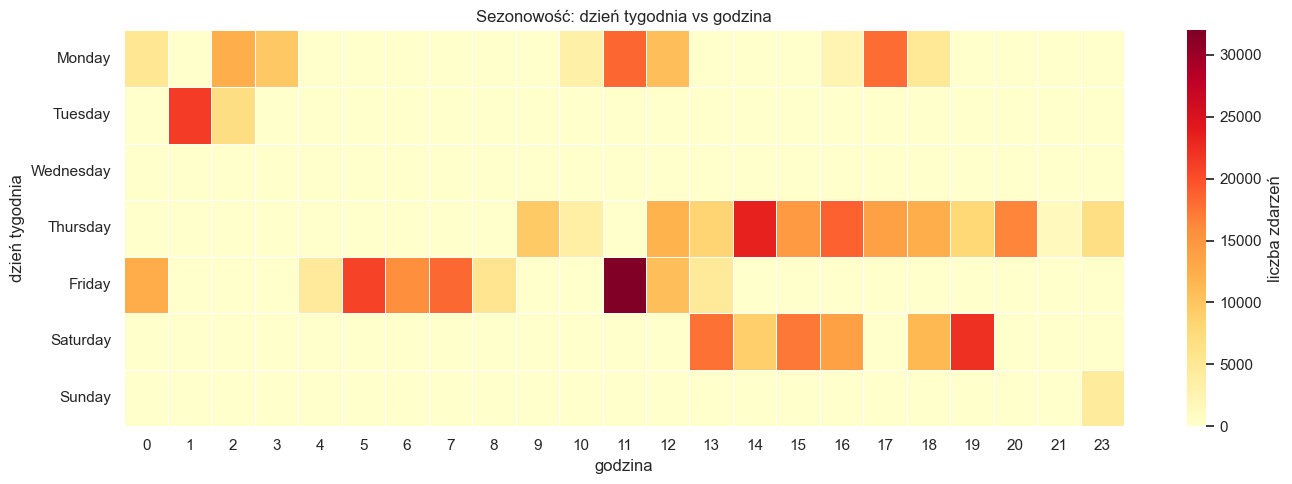

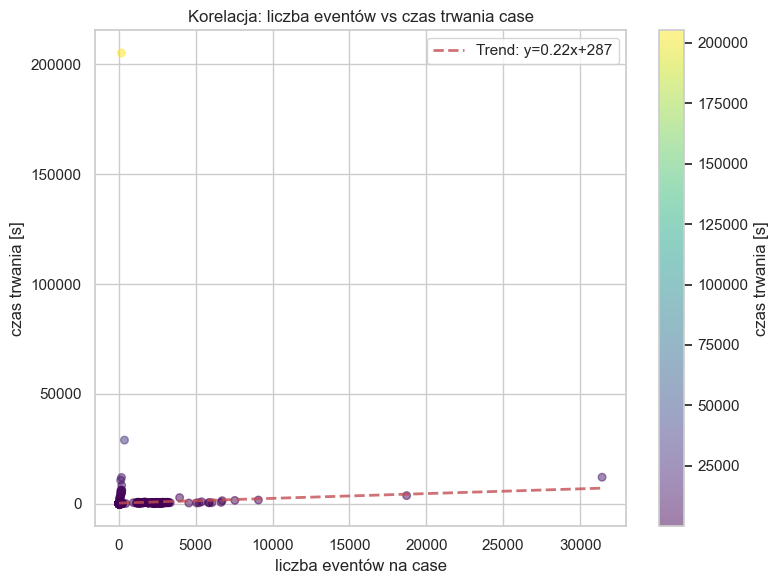

Korelacja Pearsona (eventy vs czas): 0.052


/var/folders/ws/p5kx9dl15g1gyphfrcyg239w0000gn/T/ipykernel_58316/1088612417.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_batch_duration, x="batch", y="duration_sec", palette="Set2")


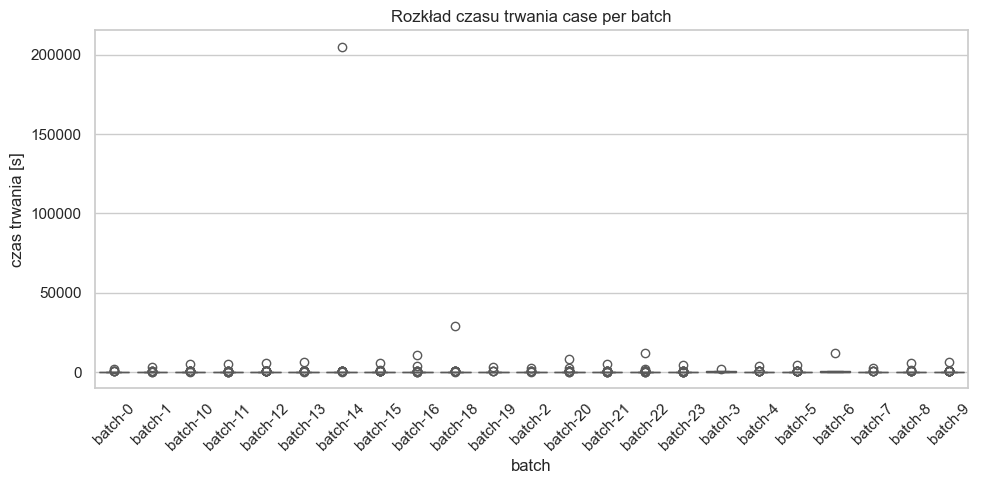


Statystyki czasu trwania per batch:
          count         mean           std       min        25%        50%         75%            max
batch                                                                                                
batch-0    29.0   166.880067    404.121786  5.491806  17.202942  30.158058   71.050144    2098.571603
batch-1    36.0   187.156065    527.683423  5.446518  18.804669  33.282217   85.482169    3136.045110
batch-10   73.0   160.658578    571.411298  5.532505  19.839480  35.844275   98.496070    4820.550298
batch-11   77.0   153.382449    592.050502  5.501711  19.839223  34.952040   90.338820    5163.036510
batch-12   78.0   176.484137    675.449253  5.537802  19.846456  33.506451   83.598191    5887.583133
batch-13   75.0   192.250607    706.490862  5.552751  24.184839  38.216820  108.495588    6060.403236
batch-14   62.0  3407.869399  26038.150429  3.726642  19.577435  28.003341   71.624278  205121.405661
batch-15   65.0   200.093809    750.841370  3

In [14]:
# Heatmapa: dzień tygodnia vs godzina (sezonowość)
if timeline_hourly:
    df_time_heatmap = pd.DataFrame({
        'timestamp': list(timeline_hourly.keys()),
        'count': list(timeline_hourly.values())
    })
    df_time_heatmap['dow'] = df_time_heatmap['timestamp'].dt.day_name()
    df_time_heatmap['hour'] = df_time_heatmap['timestamp'].dt.hour

    heat = pd.crosstab(df_time_heatmap['dow'], df_time_heatmap['hour'], 
                       values=df_time_heatmap['count'], aggfunc='sum').fillna(0)
    ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    heat = heat.reindex(ordered_days).fillna(0)

    plt.figure(figsize=(14, 5))
    sns.heatmap(heat, cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': 'liczba zdarzeń'})
    plt.title("Sezonowość: dzień tygodnia vs godzina")
    plt.xlabel("godzina")
    plt.ylabel("dzień tygodnia")
    plt.tight_layout()
    plt.show()

# Scatterplot: liczba eventów vs czas trwania case
if case_events and case_min_ts:
    duration_map = {
        k: (case_max_ts[k] - case_min_ts[k]).total_seconds()
        for k in case_events
        if k in case_min_ts and k in case_max_ts
    }
    scatter_df = pd.DataFrame({
        'events': [case_events[k] for k in duration_map],
        'duration': list(duration_map.values())
    }).dropna()

    plt.figure(figsize=(8, 6))
    plt.scatter(scatter_df['events'], scatter_df['duration'], alpha=0.5, s=30, c=scatter_df['duration'], cmap='viridis')
    plt.xlabel("liczba eventów na case")
    plt.ylabel("czas trwania [s]")
    plt.title("Korelacja: liczba eventów vs czas trwania case")
    plt.colorbar(label="czas trwania [s]")
    
    # Dodaj linię trendu
    z = np.polyfit(scatter_df['events'].dropna(), scatter_df['duration'].dropna(), 1)
    p = np.poly1d(z)
    plt.plot(scatter_df['events'].sort_values(), p(scatter_df['events'].sort_values()), 
             "r--", alpha=0.8, linewidth=2, label=f"Trend: y={z[0]:.2f}x+{z[1]:.0f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Statystyka korelacji
    corr = scatter_df['events'].corr(scatter_df['duration'])
    print(f"Korelacja Pearsona (eventy vs czas): {corr:.3f}")

# Boxplot: rozkład czasu trwania case per batch
if not durations_series.empty and case_batch:
    # Zbuduj DataFrame z duration per batch używając case_batch
    df_batch_duration_list = []
    for case_key, duration_sec in zip(case_events.keys(), durations_series):
        batch_name = case_batch.get(case_key, "unknown")
        df_batch_duration_list.append({"batch": batch_name, "duration_sec": duration_sec})

    if df_batch_duration_list:
        df_batch_duration = pd.DataFrame(df_batch_duration_list)
        
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df_batch_duration, x="batch", y="duration_sec", palette="Set2")
        plt.title("Rozkład czasu trwania case per batch")
        plt.xlabel("batch")
        plt.ylabel("czas trwania [s]")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Statystyka per batch
        print("\nStatystyki czasu trwania per batch:")
        print(df_batch_duration.groupby("batch")["duration_sec"].describe())

